In [12]:
import pandas as pd
import matplotlib.pyplot as plt

def load_data(path, version_label):
    """Carica un file CSV e aggiunge l'etichetta della versione."""
    df = pd.read_csv(path, sep=",", header="infer")
    df['version'] = version_label
    return df

def load_all_data():
    """Carica e unifica tutti i dataset con le rispettive etichette."""
    df_scalar   = load_data('./parallel/results_parallel.data', 'Scalare')
    df_simd     = load_data('./parallel/results_parallel_simd.data', 'SIMD')
    df_soa      = load_data('./parallel/results_parallel_soa.data', 'SIMD/SoA')

    return pd.concat([df_scalar, df_simd, df_soa], ignore_index=True)

def load_sequential_data(filepath_or_buffer):
    """Carica i dati del benchmark sequenziale."""
    df_seq = pd.read_csv(filepath_or_buffer, skipinitialspace=True)
    # Rinomina per evitare collisioni nei merge
    df_seq = df_seq.rename(columns={'total_time': 'seq_time'})
    return df_seq

def plot_speedup_all_vs_sequential(df_parallel, df_seq, metric='total_time', show_values=True):
    """
    Calcola e plotta lo Speedup di ogni versione parallela (Scalare, SIMD, SIMD/SoA)
    rispetto alla versione Sequenziale, suddiviso per tipologia di network:
    Speedup = Tempo_Sequenziale / Tempo_Parallelo
    """
    # 1. Unione sui soli valori di 'bodies' presenti in entrambi i dataset
    merged = pd.merge(df_parallel, df_seq, on='bodies', how='inner')

    if merged.empty:
        print("Attenzione: nessun valore di 'bodies' combacia tra sequenziale e parallelo!")
        return

    # 2. Calcolo Speedup puntuale
    merged['speedup_vs_seq'] = merged['seq_time'] / merged[metric]

    # Stili per distinguere chiaramente le versioni
    styles = {
        'Scalare':  {'color': '#1f77b4', 'marker': 'o', 'linestyle': '-'},
        'SIMD':     {'color': '#ff7f0e', 'marker': 's', 'linestyle': '--'},
        'SIMD/SoA': {'color': '#2ca02c', 'marker': '^', 'linestyle': '-.'}
    }

    networks = merged['network'].unique()
    fig, axes = plt.subplots(1, len(networks), figsize=(7 * len(networks), 6), sharey=True)
    if len(networks) == 1:
        axes = [axes]

    for ax, net in zip(axes, networks):
        subset_net = merged[merged['network'] == net]

        for ver in ['Scalare', 'SIMD', 'SIMD/SoA']:
            subset = subset_net[subset_net['version'] == ver].sort_values(by='bodies')
            if subset.empty:
                continue

            line = ax.plot(
                subset['bodies'],
                subset['speedup_vs_seq'],
                label=f'{ver}',
                linewidth=2,
                markersize=7,
                **styles.get(ver, {})
            )

            # 3. Annotazione opzionale con il valore numerico esatto sul marker
            if show_values:
                for _, row in subset.iterrows():
                    val = row['speedup_vs_seq']
                    ax.annotate(
                        f'{val:.1f}x',
                        (row['bodies'], val),
                        textcoords="offset points",
                        xytext=(0, 7),
                        ha='center',
                        fontsize=8,
                        fontweight='bold',
                        color=styles.get(ver, {}).get('color', 'black')
                    )

        # Baseline sequenziale = 1.0x
        ax.axhline(1.0, color='gray', linestyle=':', linewidth=1.5, label='Baseline (Seq = 1.0x)')

        # Linea ideale (Speedup teorico = numero di processi) se 'processors' è definito
        if 'processors' in subset_net.columns:
            n_proc = subset_net['processors'].iloc[0]
            ax.axhline(n_proc, color='red', linestyle='--', alpha=0.6, label=f'Ideale Lineare ({n_proc}x)')

        ax.set_title(f'Rete: {net}', fontsize=13, fontweight='bold', pad=12)
        ax.set_xlabel('Numero di Bodies', fontsize=11)
        ax.set_xticks(subset_net['bodies'].unique())
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend(title='Implementazione', fontsize=9)

    axes[0].set_ylabel(f'Speedup su {metric} (x volte)', fontsize=11)
    plt.suptitle(f'Speedup delle Versioni Parallele rispetto al Sequenziale ({metric})', fontsize=14, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

    # 4. Stampa a console della tabella riassuntiva dei valori numerici
    summary_table = merged.pivot_table(
        index=['network', 'bodies'],
        columns='version',
        values='speedup_vs_seq'
    ).round(2)

    print("\n--- Tabella Speedup vs Sequenziale (x volte) ---")
    print(summary_table)

def plot_version_comparison(df, metric='total_time'):
    networks = df['network'].unique()
    fig, axes = plt.subplots(1, len(networks), figsize=(6 * len(networks), 5), sharey=True)
    if len(networks) == 1:
        axes = [axes]

    styles = {
        'Scalare':  {'color': '#1f77b4', 'marker': 'o', 'linestyle': '-'},
        'SIMD':     {'color': '#ff7f0e', 'marker': 's', 'linestyle': '--'},
        'SIMD/SoA': {'color': '#2ca02c', 'marker': '^', 'linestyle': '-.'}
    }

    metric_labels = {
        'total_time': 'Total Time (s)',
        'cpu_time':   'CPU Time (s)',
        'net_time':   'Network Time (s)'
    }

    for ax, net in zip(axes, networks):
        subset_net = df[df['network'] == net]
        for ver in ['Scalare', 'SIMD', 'SIMD/SoA']:
            subset = subset_net[subset_net['version'] == ver].sort_values(by='bodies')
            if not subset.empty:
                ax.plot(
                    subset['bodies'],
                    subset[metric],
                    label=ver,
                    **styles[ver],
                    linewidth=2,
                    markersize=7
                )

        # pad=12 aggiunge respiro sopra il singolo asse
        ax.set_title(f'Rete: {net}', fontsize=13, fontweight='bold', pad=12)
        ax.set_xlabel('Numero di Bodies', fontsize=11)
        ax.set_xticks(df['bodies'].unique())
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend(title='Implementazione', fontsize=10)

    axes[0].set_ylabel(metric_labels.get(metric, metric), fontsize=11)

    # y=0.98 posiziona il titolo globale dentro i confini superiori
    plt.suptitle(f'Confronto Prestazioni: {metric_labels.get(metric, metric)}', fontsize=14, y=0.98)

    # rect=[left, bottom, right, top]: lascia il 10% di margine superiore per i titoli
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()


def plot_speedup_vs_scalar(df, metric='total_time'):
    pivot = df.pivot_table(index=['network', 'bodies'], columns='version', values=metric).reset_index()

    pivot['Speedup SIMD']     = pivot['Scalare'] / pivot['SIMD']
    pivot['Speedup SIMD/SoA'] = pivot['Scalare'] / pivot['SIMD/SoA']

    networks = pivot['network'].unique()
    fig, axes = plt.subplots(1, len(networks), figsize=(6 * len(networks), 5), sharey=True)
    if len(networks) == 1:
        axes = [axes]

    for ax, net in zip(axes, networks):
        subset = pivot[pivot['network'] == net].sort_values(by='bodies')

        ax.plot(subset['bodies'], subset['Speedup SIMD'], marker='s', label='Speedup SIMD', color='#ff7f0e', linewidth=2)
        ax.plot(subset['bodies'], subset['Speedup SIMD/SoA'], marker='^', label='Speedup SIMD/SoA', color='#2ca02c', linewidth=2)

        ax.axhline(1.0, color='gray', linestyle=':', linewidth=1.5, label='Baseline (Scalare = 1.0x)')

        ax.set_title(f'Rete: {net}', fontsize=13, fontweight='bold', pad=12)
        ax.set_xlabel('Numero di Bodies', fontsize=11)
        ax.set_xticks(pivot['bodies'].unique())
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend(fontsize=10)

    axes[0].set_ylabel(f'Speedup su {metric} (x volte)', fontsize=11)
    plt.suptitle(f'Speedup Relativo alla Versione Scalare ({metric})', fontsize=14, y=0.98)

    # rect=[0, 0, 1, 0.92] protegge l'area superiore
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()


def plot_speedup_single_version_all_networks(df_parallel, df_seq, version='SIMD/SoA', metric='total_time', show_values=True):
  """
  Traccia su un singolo grafico lo Speedup rispetto al Sequenziale di una specifica versione
  mettendo a confronto tutte le reti disponibili:
  Speedup = Tempo_Sequenziale / Tempo_Parallelo
  """
  # 1. Filtra per la versione richiesta e fai il merge con il sequenziale
  df_ver = df_parallel[df_parallel['version'] == version]
  merged = pd.merge(df_ver, df_seq, on='bodies', how='inner')

  if merged.empty:
      print(f"Attenzione: nessun dato combaciante trovato per la versione '{version}'!")
      return

  # 2. Calcolo dello Speedup puntuale
  merged['speedup_vs_seq'] = merged['seq_time'] / merged[metric]

  # Stili per distinguere visivamente le reti
  network_styles = {
      'tcpip/ethernet': {'color': '#1f77b4', 'marker': 'o', 'linestyle': '-'},
      'tcpip/infiniband': {'color': '#2ca02c', 'marker': 's', 'linestyle': '--'},
      'native/infiniband':   {'color': '#d62728', 'marker': '^', 'linestyle': '-.'},
      # Fallback generico per nomi di rete non standard
      'default':      {'color': '#9467bd', 'marker': 'D', 'linestyle': ':'}
  }

  plt.figure(figsize=(9, 6))

  networks = merged['network'].unique()
  for net in networks:
      subset = merged[merged['network'] == net].sort_values(by='bodies')
      if subset.empty:
          continue

      style = network_styles.get(net, network_styles['default'])

      plt.plot(
          subset['bodies'],
          subset['speedup_vs_seq'],
          label=f'Rete: {net}',
          linewidth=2,
          markersize=7,
          **style
      )

      if show_values:
          for _, row in subset.iterrows():
              val = row['speedup_vs_seq']
              plt.annotate(
                  f"{val:.1f}x",
                  (row['bodies'], val),
                  textcoords="offset points",
                  xytext=(0, 6),
                  ha='center',
                  fontsize=8,
                  fontweight='bold',
                  color=style['color']
              )

  # Linea di baseline sequenziale (1.0x)
  plt.axhline(1.0, color='gray', linestyle=':', linewidth=1.5, label='Baseline (Seq = 1.0x)')

  # Eventuale linea ideale teorica se la colonna 'processors' esiste
  if 'processors' in merged.columns:
      n_proc = merged['processors'].iloc[0]
      plt.axhline(n_proc, color='black', linestyle='--', alpha=0.5, label=f'Ideale Lineare ({n_proc}x)')

  plt.title(f'Confronto Reti - Speedup vs Sequenziale ({version})', fontsize=13, fontweight='bold', pad=12)
  plt.xlabel('Numero di Bodies', fontsize=11)
  plt.ylabel(f'Speedup su {metric} (x volte)', fontsize=11)
  plt.xticks(sorted(merged['bodies'].unique()))
  plt.grid(True, linestyle='--', alpha=0.6)
  plt.legend(title='Interconnessione', fontsize=9)
  plt.tight_layout()
  plt.show()

  # Tabella riassuntiva a video
  summary_table = merged.pivot_table(
      index='bodies',
      columns='network',
      values='speedup_vs_seq'
  ).round(2)

  print(f"\n--- Tabella Speedup {version} vs Sequenziale (x volte) ---")
  print(summary_table)


def plot_cache_misses(df, log_scale=True):
    """
    Traccia i Cache Miss L1 e L2 per ciascuna versione (Scalare, SIMD, SIMD/SoA)
    al variare del numero di bodies, suddiviso per tipologia di rete.
    """
    networks = df['network'].unique()
    styles = {
        'Scalare':  {'color': '#1f77b4', 'marker': 'o', 'linestyle': '-'},
        'SIMD':     {'color': '#ff7f0e', 'marker': 's', 'linestyle': '--'},
        'SIMD/SoA': {'color': '#2ca02c', 'marker': '^', 'linestyle': '-.'}
    }

    # Griglia 2 righe (L1, L2) x N colonne (una per ogni rete)
    fig, axes = plt.subplots(2, len(networks), figsize=(6 * len(networks), 9), sharex=True)

    # Normalizza la forma di axes se c'è una sola rete
    if len(networks) == 1:
        axes = axes.reshape(2, 1)

    for col_idx, net in enumerate(networks):
        subset_net = df[df['network'] == net]

        # Riga 0 -> L1 Miss, Riga 1 -> L2 Miss
        for row_idx, (col_name, label_name) in enumerate([('cache_miss_L1', 'L1 Cache Miss'),
                                                          ('cache_miss_L2', 'L2 Cache Miss')]):
            ax = axes[row_idx, col_idx]

            for ver in ['Scalare', 'SIMD', 'SIMD/SoA']:
                subset = subset_net[subset_net['version'] == ver].sort_values(by='bodies')
                if not subset.empty:
                    ax.plot(
                        subset['bodies'],
                        subset[col_name],
                        label=ver,
                        linewidth=2,
                        markersize=6,
                        **styles.get(ver, {})
                    )

            if log_scale:
                ax.set_yscale('log')

            if row_idx == 0:
                ax.set_title(f'Rete: {net}', fontsize=12, fontweight='bold', pad=10)

            if col_idx == 0:
                scale_suffix = " (log scale)" if log_scale else ""
                ax.set_ylabel(f'{label_name}{scale_suffix}', fontsize=11)

            if row_idx == 1:
                ax.set_xlabel('Numero di Bodies', fontsize=11)
                ax.set_xticks(sorted(df['bodies'].unique()))

            ax.grid(True, which='both', linestyle='--', alpha=0.5)
            ax.legend(title='Versione', fontsize=9)

    plt.suptitle('Analisi Cache Miss L1 e L2 (PAPI)', fontsize=14, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


def plot_cache_miss_reduction(df, target_cache='cache_miss_L1'):
    """
    Mostra la percentuale di miss risparmiati da SIMD e SIMD/SoA
    rispetto alla versione Scalare:
    Riduzione % = (Miss_Scalare - Miss_Target) / Miss_Scalare * 100
    """
    pivot = df.pivot_table(index=['network', 'bodies'], columns='version', values=target_cache).reset_index()

    if 'Scalare' not in pivot.columns:
        print("Errore: Versione 'Scalare' mancante per il calcolo della riduzione.")
        return

    networks = pivot['network'].unique()
    fig, axes = plt.subplots(1, len(networks), figsize=(6 * len(networks), 5), sharey=True)
    if len(networks) == 1:
        axes = [axes]

    cache_label = "L1" if "L1" in target_cache else "L2"

    for ax, net in zip(axes, networks):
        subset = pivot[pivot['network'] == net].sort_values(by='bodies')

        for ver, color, marker in [('SIMD', '#ff7f0e', 's'), ('SIMD/SoA', '#2ca02c', '^')]:
            if ver in subset.columns:
                reduction = ((subset['Scalare'] - subset[ver]) / subset['Scalare']) * 100
                ax.plot(subset['bodies'], reduction, label=f'Riduzione {ver}', marker=marker, color=color, linewidth=2)

        ax.axhline(0, color='gray', linestyle=':', linewidth=1.2, label='Nessun miglioramento (0%)')
        ax.set_title(f'Rete: {net}', fontsize=12, fontweight='bold', pad=10)
        ax.set_xlabel('Numero di Bodies', fontsize=11)
        ax.set_xticks(sorted(pivot['bodies'].unique()))
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend(fontsize=9)

    axes[0].set_ylabel(f'Riduzione % Miss {cache_label} vs Scalare', fontsize=11)
    plt.suptitle(f'Efficienza di Accesso alla Memoria: Riduzione {cache_label} Cache Miss', fontsize=14, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

In [13]:
df_all = load_all_data()
df_seq = load_sequential_data("./sequential/results.data")

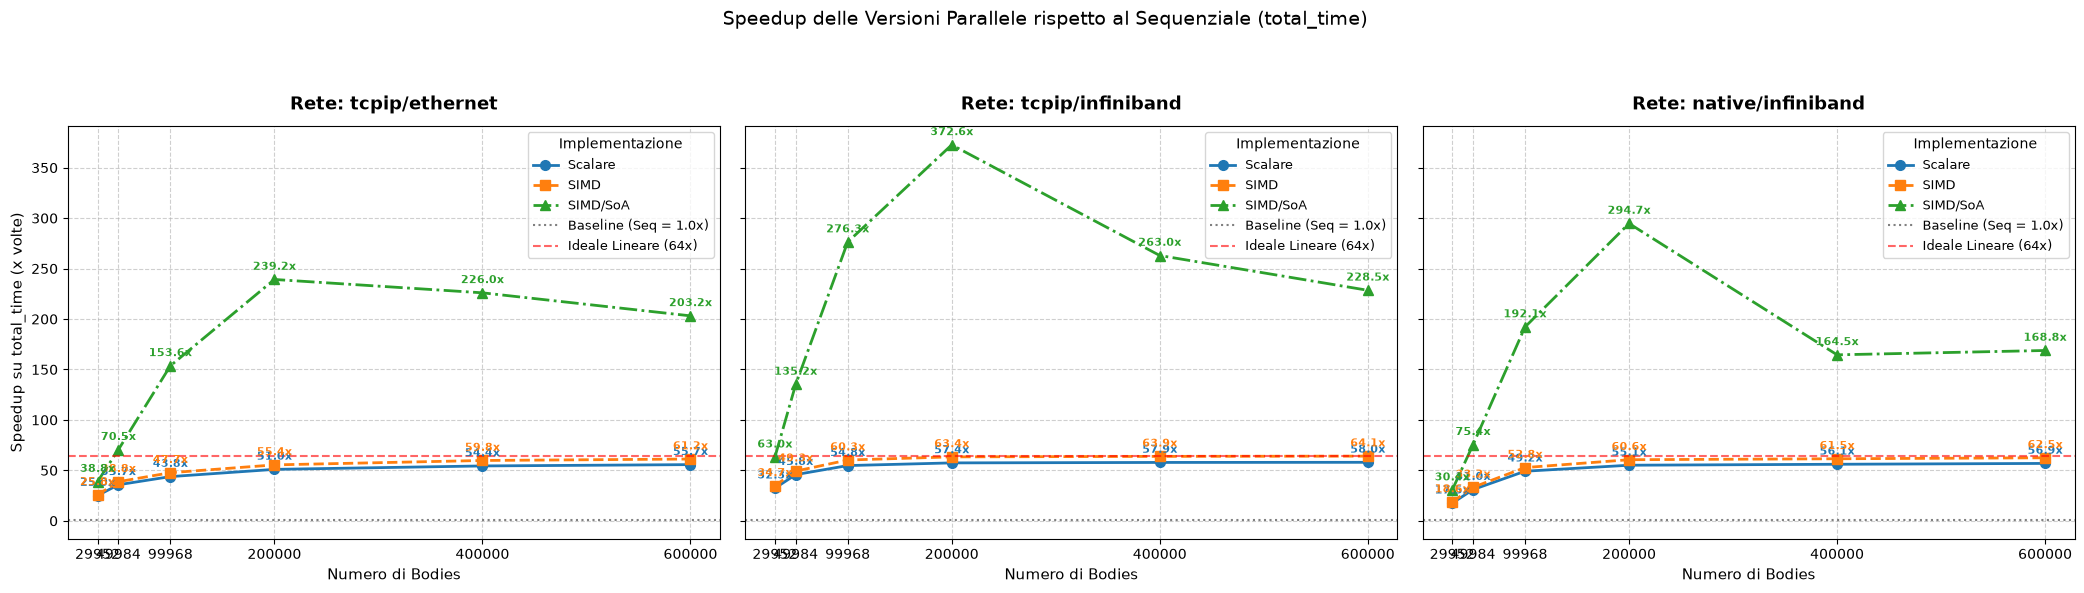


--- Tabella Speedup vs Sequenziale (x volte) ---
version                    SIMD  SIMD/SoA  Scalare
network           bodies                          
native/infiniband 29952   18.61     30.43    17.45
                  49984   33.23     75.43    30.95
                  99968   52.78    192.11    49.16
                  200000  60.56    294.70    55.11
                  400000  61.50    164.53    56.05
                  600000  62.48    168.83    56.89
tcpip/ethernet    29952   25.77     38.83    25.04
                  49984   38.77     70.50    35.74
                  99968   47.68    153.62    43.82
                  200000  55.44    239.22    50.99
                  400000  59.80    225.99    54.39
                  600000  61.23    203.16    55.70
tcpip/infiniband  29952   34.70     63.01    32.30
                  49984   49.26    135.18    45.78
                  99968   60.25    276.31    54.75
                  200000  63.38    372.64    57.41
                  400000  63.87 

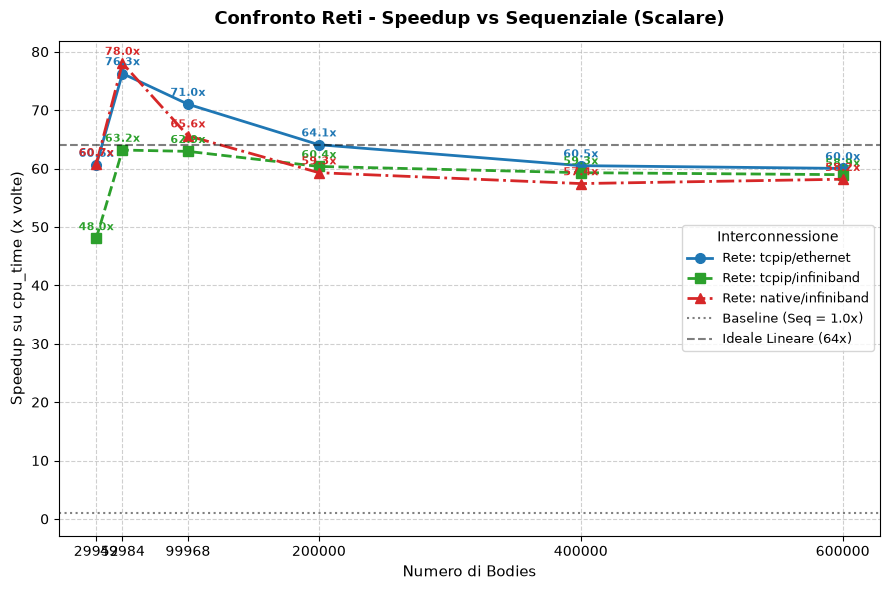


--- Tabella Speedup Scalare vs Sequenziale (x volte) ---
network  native/infiniband  tcpip/ethernet  tcpip/infiniband
bodies                                                      
29952                60.72           60.57             48.01
49984                78.04           76.27             63.16
99968                65.61           71.01             62.94
200000               59.28           64.07             60.35
400000               57.42           60.49             59.28
600000               58.17           60.01             58.95


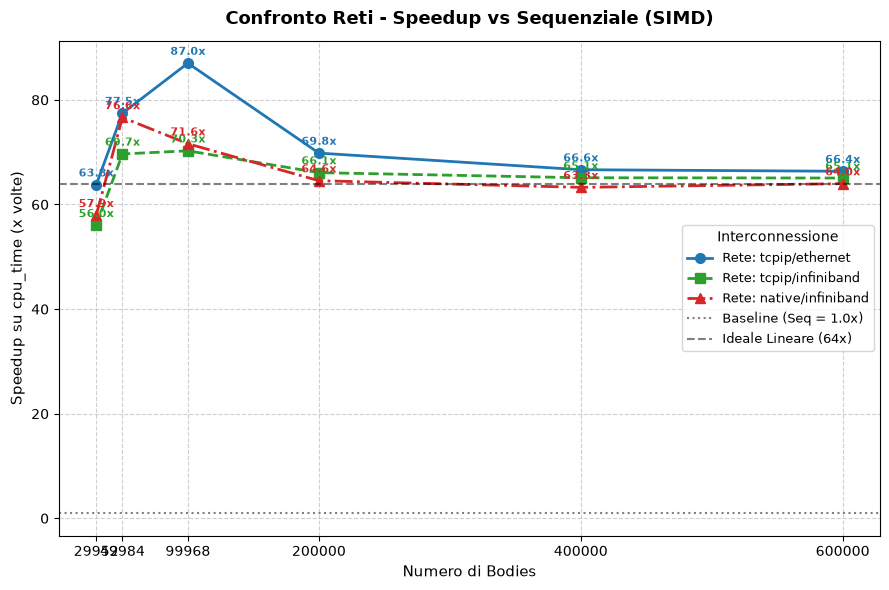


--- Tabella Speedup SIMD vs Sequenziale (x volte) ---
network  native/infiniband  tcpip/ethernet  tcpip/infiniband
bodies                                                      
29952                57.92           63.76             56.01
49984                76.63           77.46             69.66
99968                71.62           87.02             70.26
200000               64.55           69.83             66.09
400000               63.28           66.65             65.11
600000               63.98           66.35             65.06


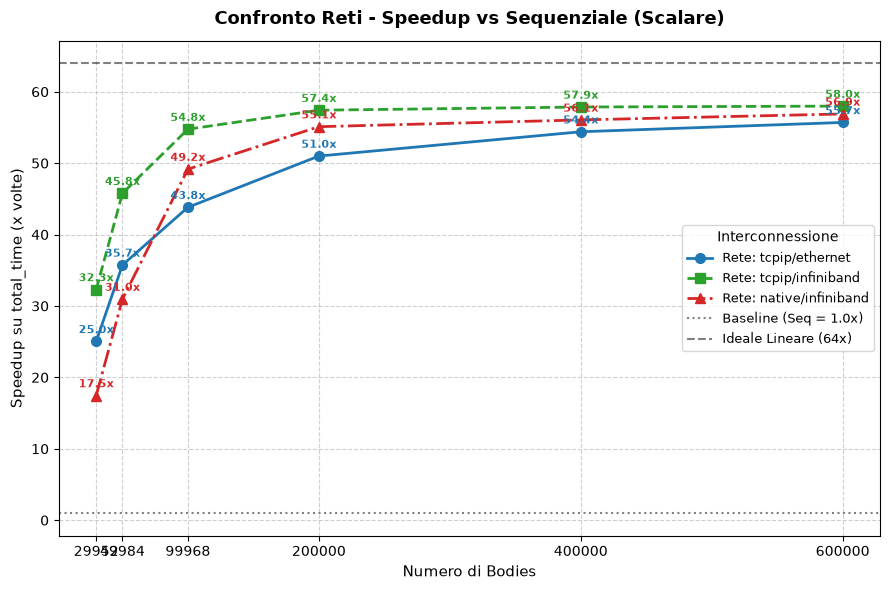


--- Tabella Speedup Scalare vs Sequenziale (x volte) ---
network  native/infiniband  tcpip/ethernet  tcpip/infiniband
bodies                                                      
29952                17.45           25.04             32.30
49984                30.95           35.74             45.78
99968                49.16           43.82             54.75
200000               55.11           50.99             57.41
400000               56.05           54.39             57.86
600000               56.89           55.70             57.99


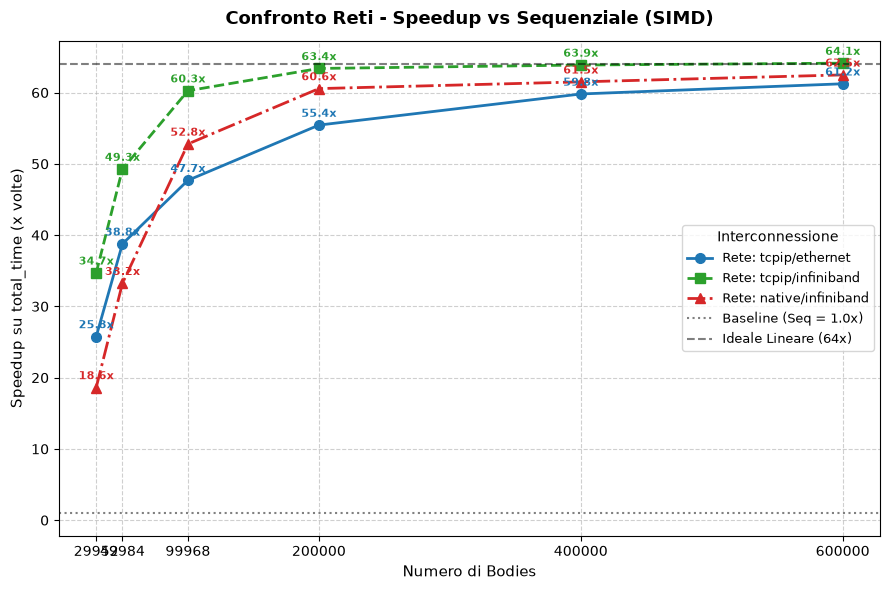


--- Tabella Speedup SIMD vs Sequenziale (x volte) ---
network  native/infiniband  tcpip/ethernet  tcpip/infiniband
bodies                                                      
29952                18.61           25.77             34.70
49984                33.23           38.77             49.26
99968                52.78           47.68             60.25
200000               60.56           55.44             63.38
400000               61.50           59.80             63.87
600000               62.48           61.23             64.13


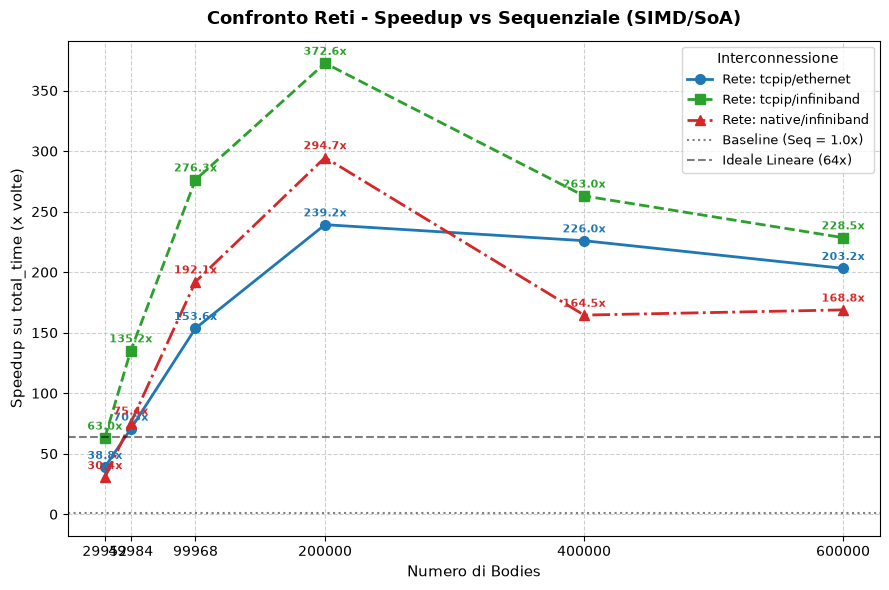


--- Tabella Speedup SIMD/SoA vs Sequenziale (x volte) ---
network  native/infiniband  tcpip/ethernet  tcpip/infiniband
bodies                                                      
29952                30.43           38.83             63.01
49984                75.43           70.50            135.18
99968               192.11          153.62            276.31
200000              294.70          239.22            372.64
400000              164.53          225.99            262.97
600000              168.83          203.16            228.49


In [14]:
plot_speedup_all_vs_sequential(df_all, df_seq, metric='total_time', show_values=True)
plot_speedup_single_version_all_networks(df_parallel=df_all, df_seq=df_seq, metric='cpu_time', show_values=True, version="Scalare")
plot_speedup_single_version_all_networks(df_parallel=df_all, df_seq=df_seq, metric='cpu_time', show_values=True, version="SIMD")

plot_speedup_single_version_all_networks(df_parallel=df_all, df_seq=df_seq, metric='total_time', show_values=True, version="Scalare")
plot_speedup_single_version_all_networks(df_parallel=df_all, df_seq=df_seq, metric='total_time', show_values=True, version="SIMD")
plot_speedup_single_version_all_networks(df_parallel=df_all, df_seq=df_seq, metric='total_time', show_values=True, version="SIMD/SoA")

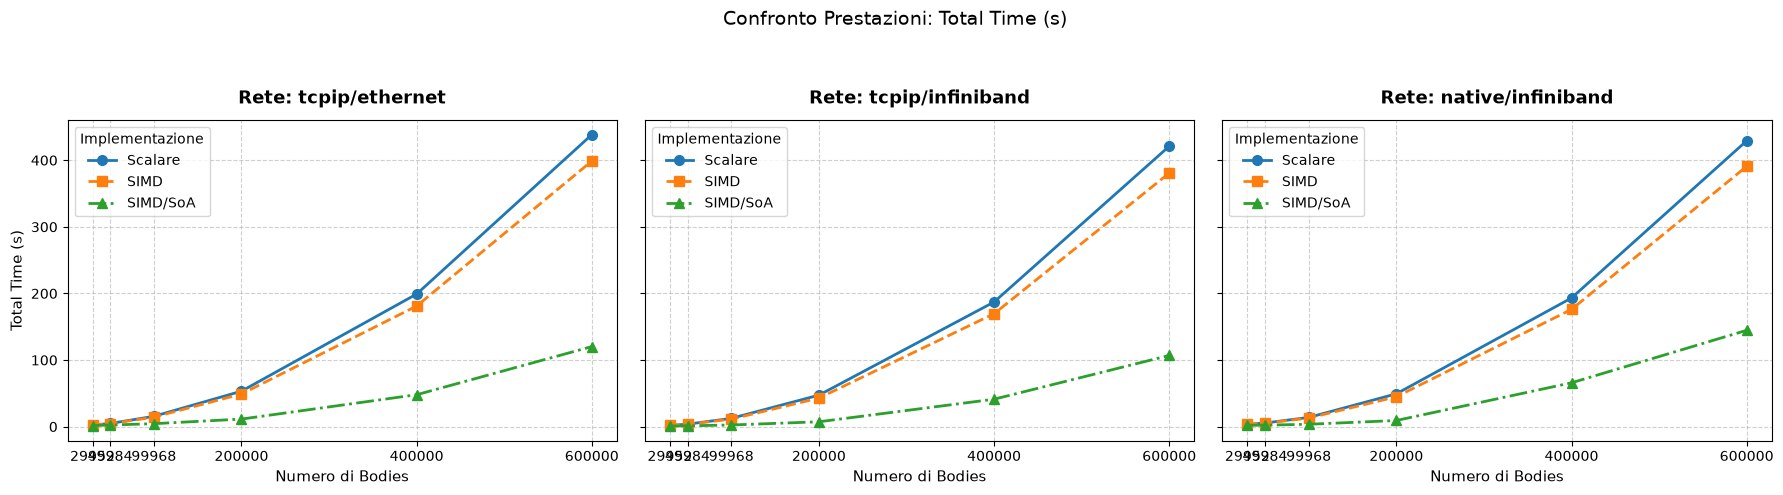

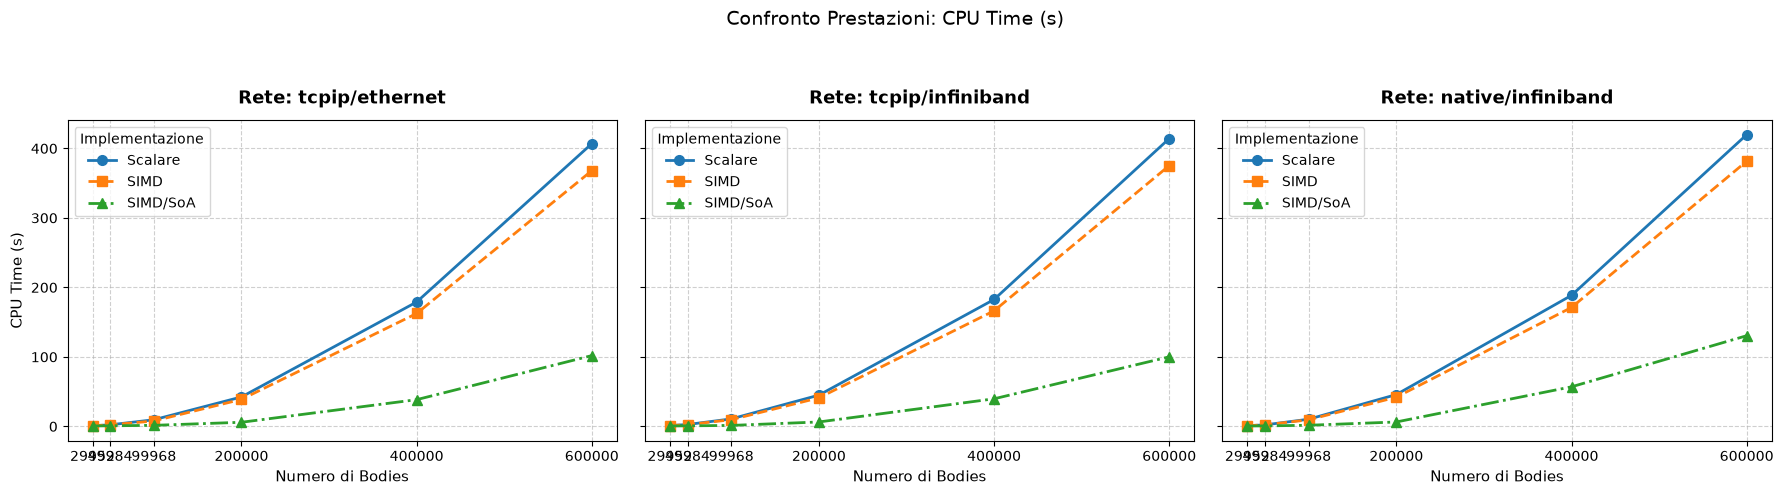

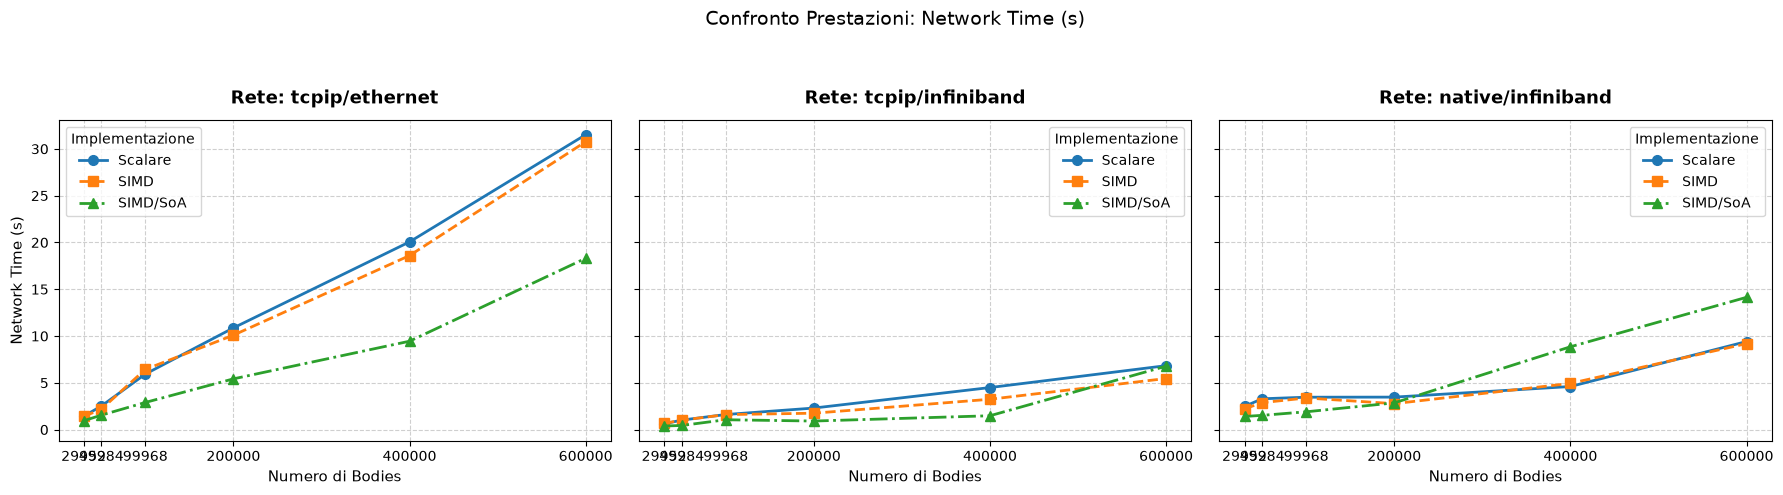

In [15]:
plot_version_comparison(df=df_all)
plot_version_comparison(df=df_all, metric="cpu_time")
plot_version_comparison(df=df_all, metric="net_time")

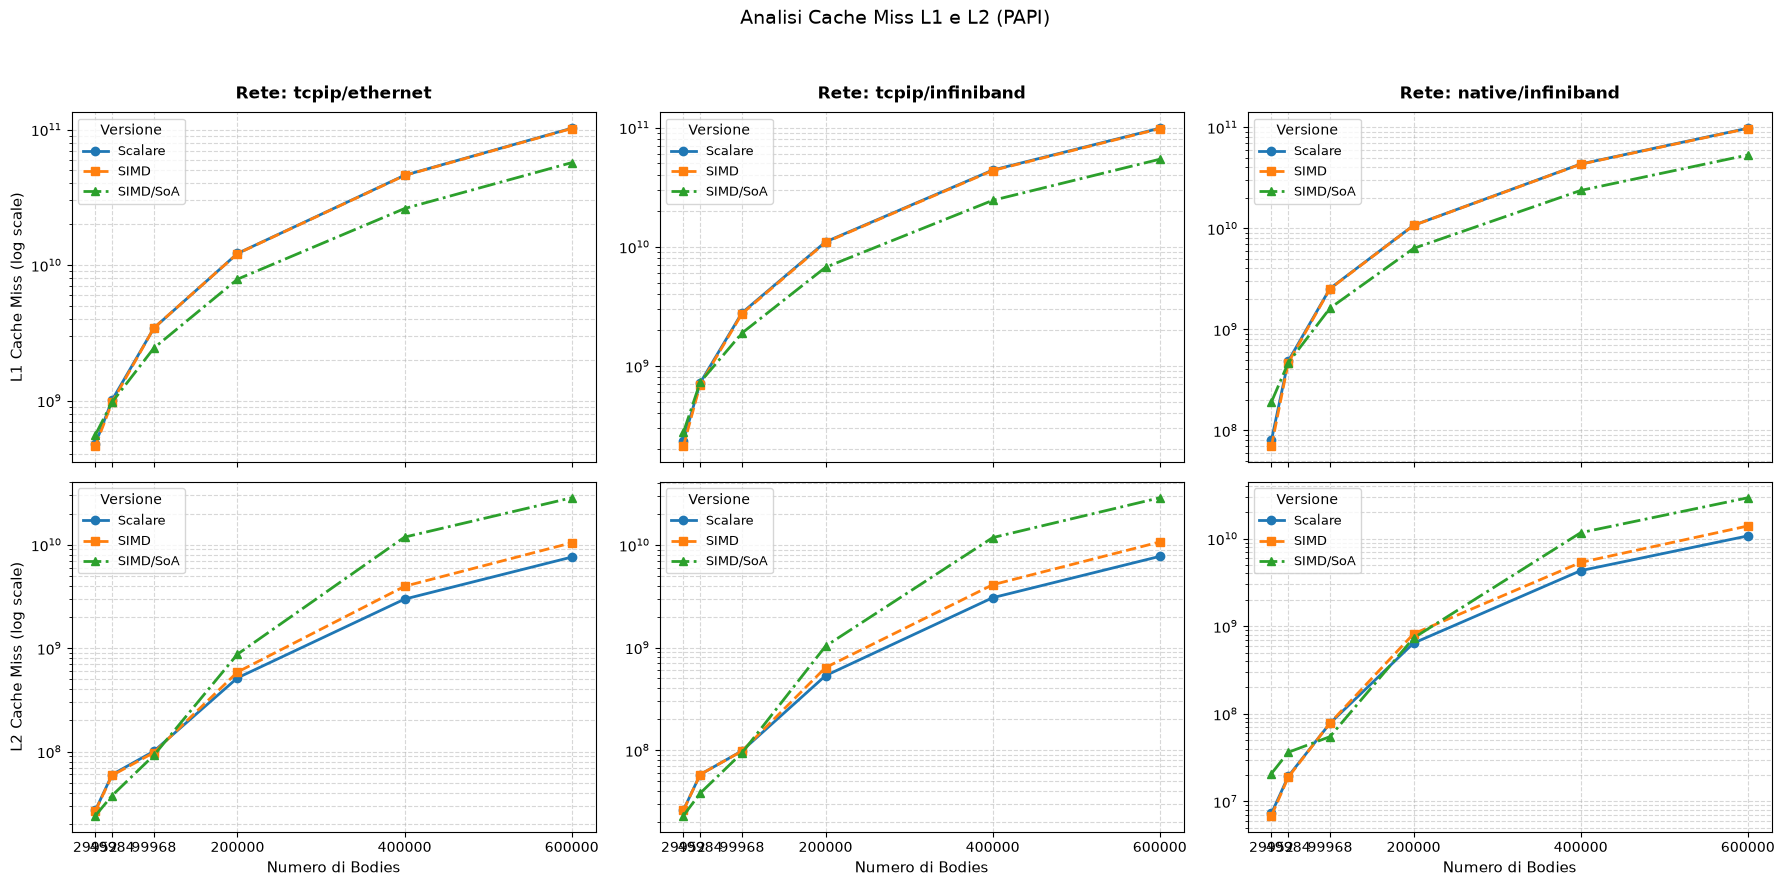

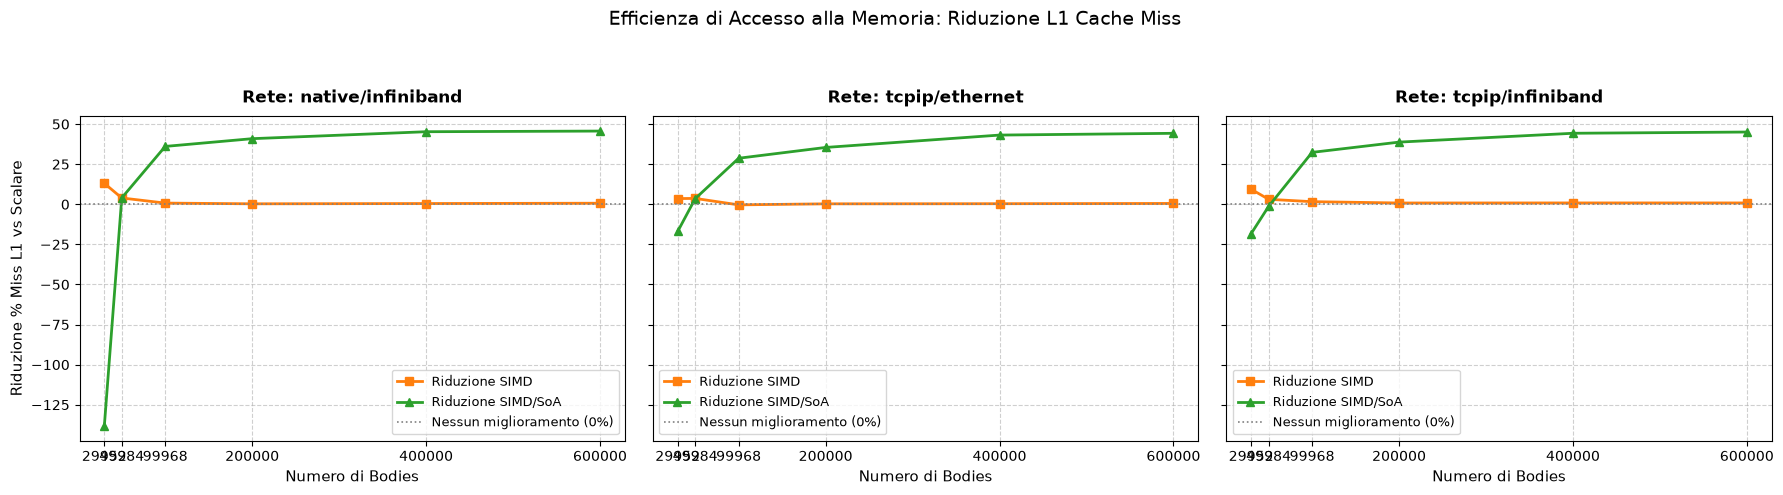

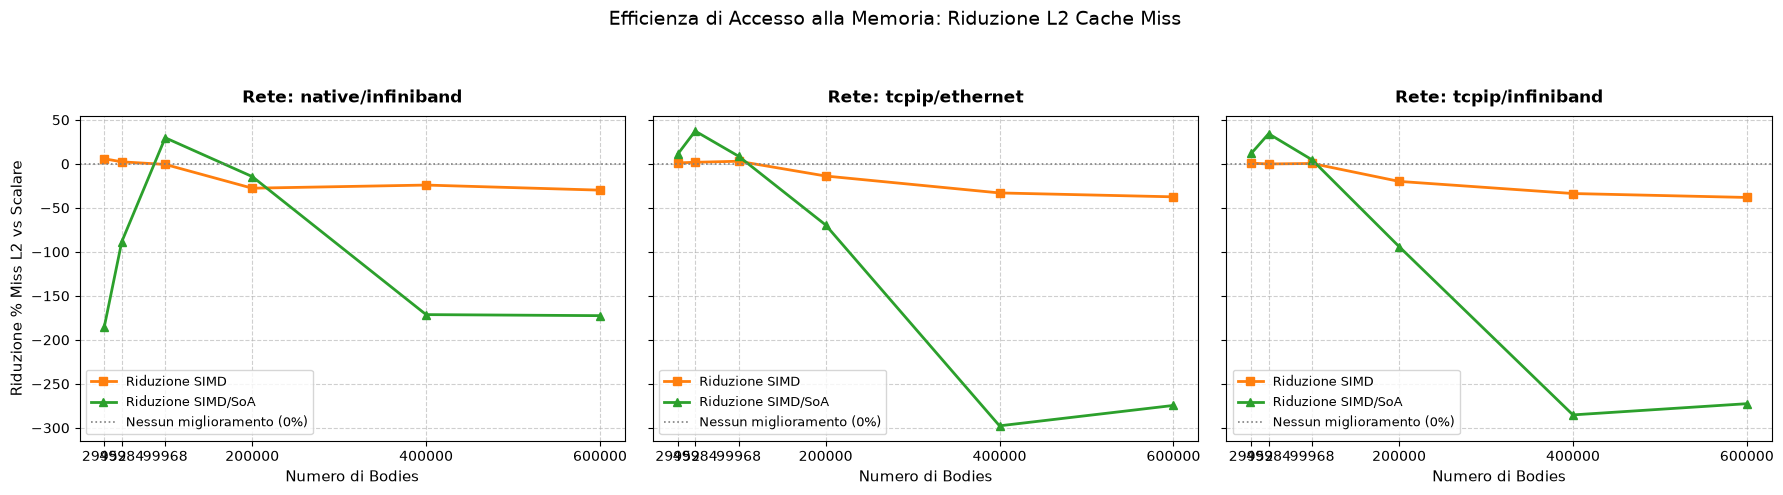

In [18]:
plot_cache_misses(df_all)

plot_cache_miss_reduction(df_all, target_cache='cache_miss_L1')
plot_cache_miss_reduction(df_all, target_cache='cache_miss_L2')